# COPER latent **sequence** → MDP state **sequence** (`copers_to_states`)

This notebook complements `coper_to_states.ipynb`, which maps a **single** patient vector `z` (last Perceiver slot) to a **histogram** over MDP states.

Here we use the **full latent grid** returned by `utils.coper_embed.latent_grid`:

- **Shape** `(batch, L, D)` where `L == num_latents` (typically **48** for the MIMIC 48-step benchmark) and `D == latent_dim`.
- **Targets** are **per-hour MDP cluster states** from the unified-build RL cohort (`mdp_cohort_<slug>.csv` → `cohort_csv_with_mdp_states`), restricted to **blocs 1 … 48** so the time axis matches the COPER tensor length.

We train a **shared** linear readout (same weights at every time index) with **cross-entropy** over **every** `(icustay, timestep)` pair in the training split (all valid stays × all `L` blocs). After training, we summarize **full-stay** agreement (fraction of timesteps correct per stay) and plot example trajectories (ground truth vs argmax predictions) on held-out splits.

## Important assumption (read carefully)

COPER’s `L` latent slots are **Perceiver queries**, not guaranteed hour-by-hour clinical clocks. Treating latent index `t` as aligned with RL **bloc `t+1`** (1-based hours) is a **working hypothesis** for analysis — useful for “does any per-step signal exist?”, not a certified temporal registration.

## Prerequisites

- Trained COPER export (same as `coper_to_states.ipynb`).
- `notebooks/build_data.ipynb` completed so `mdp_cohort_<slug>.csv` and `mdp_params_<slug>/` exist under `data_mngmt/generated/unified/<slug>/`.
- **Kernel cwd:** the first code cell walks parents from `Path.cwd()` to find the repo root and **prepends it to `sys.path` before** importing `data_mngmt` (so it works from `notebooks/` or the repo root).


In [7]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path


def _resolve_bench_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "utils" / "load_coper_bundle.py").exists() and (p / "src_coper").exists():
            return p
    raise RuntimeError("Could not resolve repo root (expected `utils/load_coper_bundle.py` + `src_coper/`).")


def _find_coper_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(12):
        if (p / "icu_sepsis" / "icu_sepsis").is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError("Could not find COPER root (icu_sepsis package).")


BENCH = _resolve_bench_root()
COPER_ROOT = _find_coper_root(BENCH)
PKG_ICU = COPER_ROOT / "icu_sepsis" / "icu_sepsis"
PKG_HELPERS = COPER_ROOT / "icu_sepsis" / "icu_sepsis_helpers"
for pkg in (BENCH, PKG_ICU, PKG_HELPERS):
    s = str(pkg)
    if s not in sys.path:
        sys.path.insert(0, s)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

from data_mngmt import mortality_pickle_path
from data_mngmt.contracts.coper_mdp_join import (
    cohort_csv_with_mdp_states,
    default_unified_cohort_paths,
    per_bloc_state_matrix,
    read_mdp_metadata_n_states,
)
from src_coper.coper_model import COPER
from src_coper.transformer_model import TRANSFORMER
from utils.coper_embed import latent_grid
from utils.embedding_data_utils import load_icustay_ids_split, load_xy_split, tensors_to_loader
from utils.load_coper_bundle import _namespace_from_hyperparams, load_meta_json
from utils.results_layout import notebook_demo_dir

import icu_sepsis  # noqa: F401 — gym registry

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

MORTALITY_PICKLE = mortality_pickle_path()
N_BLOCS = 48
EMBED_BATCH_SIZE = 128
TRAIN_BATCH_SIZE = 128
MAX_EPOCHS = 40
PATIENCE = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

HEAD_EXPORT_DIR = notebook_demo_dir("models", "copers_to_states", BENCH)

_latest_models_marker = BENCH / "results" / "latest_mimic_compare_models_dir.txt"
_run_dirs = sorted((BENCH / "results" / "runs").glob("*_mimic_compare"), key=lambda p: p.name)
_res_base = _run_dirs[-1] if _run_dirs else (BENCH / "results")
if _latest_models_marker.is_file():
    _candidate = Path(_latest_models_marker.read_text(encoding="utf-8").strip())
    MODELS_DIR = _candidate if _candidate.is_dir() else (_res_base / "models")
else:
    MODELS_DIR = _res_base / "models"

MODEL_CANDIDATES = [
    "coper_2node_drop0.5_s1_e3",
    "coper_2node_drop0.5_s1_e1",
    "coper_2node_drop0_s1_e10",
    "coper_2node_drop0_s1_e3",
    "coper_2node_drop0_s1_e1",
]

print("BENCH", BENCH)
print("DEVICE", DEVICE)
print("MORTALITY_PICKLE", MORTALITY_PICKLE)
print("MODELS_DIR", MODELS_DIR)
print("HEAD_EXPORT_DIR", HEAD_EXPORT_DIR)


BENCH /home/charlesv/Desktop/StatisitcalGenetics/code/COPER
DEVICE cuda
MORTALITY_PICKLE /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/mortality_coper_sepsis-60m-h48ihm.data
MODELS_DIR /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/runs/2026-04-10_mimic_compare/models
HEAD_EXPORT_DIR /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/copers_to_states/models


In [8]:
def _instantiate_model_from_meta(meta: dict, state_dict: dict[str, torch.Tensor], device: torch.device):
    h = meta["hyperparams"]
    args = _namespace_from_hyperparams(h)
    if any(str(k).startswith("ode_out.") for k in state_dict.keys()):
        args.second_node = True
    model_type = str(h.get("model_type", "COPER")).upper()
    model_cls = TRANSFORMER if model_type == "TRANSFORMER" else COPER
    model = model_cls(
        args,
        1,
        h.get("input_size_mimic", 76),
        args.num_latents,
        args.latent_dim,
        args.rec_layers,
        args.units,
        nn.Tanh,
        args.cont_in,
        args.cont_out,
        emb_dim=args.emb_dim,
        device=device,
    ).to(device)
    model.load_state_dict(state_dict, strict=True)
    model.eval()
    return model


def _load_state_dict(weight_path: Path, device: torch.device) -> dict[str, torch.Tensor]:
    raw = torch.load(weight_path, map_location=device)
    if isinstance(raw, dict) and "model_state_dict" in raw:
        return raw["model_state_dict"]
    if isinstance(raw, dict) and "state_dict" in raw:
        return raw["state_dict"]
    return raw


def _candidate_model_dirs() -> list[Path]:
    dirs: list[Path] = []
    if MODELS_DIR.exists():
        dirs.append(MODELS_DIR)
    legacy = BENCH / "results" / "models"
    if legacy.exists() and legacy not in dirs:
        dirs.append(legacy)
    runs_root = BENCH / "results" / "runs"
    if runs_root.is_dir():
        for rd in sorted(runs_root.glob("*_mimic_compare"), key=lambda p: p.name, reverse=True):
            md = rd / "models"
            if md.exists() and md not in dirs:
                dirs.append(md)
    return dirs


def resolve_model(candidates: list[str]):
    attempted = []
    searched_model_dirs = [str(p) for p in _candidate_model_dirs()]
    if not searched_model_dirs:
        raise FileNotFoundError("No model dirs under results/. Train/export in COPERvsTRANSFORMER_mortality.ipynb first.")
    for model_dir in [Path(p) for p in searched_model_dirs]:
        for stem in candidates:
            json_path = model_dir / f"{stem}.json"
            pt_path = model_dir / f"{stem}.pt"
            if not json_path.is_file():
                continue
            meta = load_meta_json(json_path)
            ckpt_path = Path(meta.get("source_checkpoint", ""))
            weight_path = pt_path if pt_path.is_file() else (ckpt_path if ckpt_path.is_file() else None)
            if weight_path is None:
                attempted.append({"stem": stem, "dir": str(model_dir), "reason": "missing weights"})
                continue
            state_dict = _load_state_dict(weight_path, DEVICE)
            model = _instantiate_model_from_meta(meta, state_dict, DEVICE)
            return {
                "stem": stem,
                "json_path": json_path,
                "weight_path": weight_path,
                "meta": meta,
                "model": model,
                "model_dir": model_dir,
                "searched_model_dirs": searched_model_dirs,
            }
    raise FileNotFoundError("No usable model weights.\n" + json.dumps(attempted, indent=2))


assert MORTALITY_PICKLE.is_file(), MORTALITY_PICKLE
MODEL_INFO = resolve_model(MODEL_CANDIDATES)
MODEL = MODEL_INFO["model"]
MODEL.eval()
print("Loaded", MODEL_INFO["stem"], "from", MODEL_INFO["weight_path"])
print("Hyperparams:", json.dumps(MODEL_INFO["meta"]["hyperparams"], indent=2))


Loaded coper_2node_drop0.5_s1_e3 from /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/runs/2026-04-10_mimic_compare/models/coper_2node_drop0.5_s1_e3.pt
Hyperparams: {
  "model_type": "COPER",
  "dataset": "mimic",
  "fold": -1,
  "drop": 0.5,
  "random_seed": 1,
  "num_latents": 48,
  "latent_dim": 64,
  "rec_layers": 3,
  "units": 128,
  "emb_dim": 32,
  "self_per_cross_attn": 1,
  "latent_heads": 2,
  "cross_heads": 1,
  "cross_dim_head": 128,
  "latent_dim_head": 128,
  "ff_dropout": 0.5,
  "att_dropout": 0.5,
  "ode_dropout": 0.5,
  "cont_in": true,
  "cont_out": false,
  "second_node": true,
  "seq_len": 48,
  "input_size_mimic": 76
}


## Rebuild cohort with MDP cluster labels (first 48 blocs)

We keep RL rows with `bloc` in `[1, N_BLOCS]` (1 h blocs) so each stay can supply exactly one state per hour in the COPER window.


In [9]:
def infer_slug_from_weight_path(weight_path: Path) -> str | None:
    p = weight_path.resolve()
    for parent in p.parents:
        if parent.name.startswith("sepsis-") or "sepsis" in parent.name:
            return parent.name
    return None


_slug = infer_slug_from_weight_path(MODEL_INFO["weight_path"])
cohort_csv, mdp_params_dir = default_unified_cohort_paths(repo_root=BENCH, slug=_slug)
if not cohort_csv.is_file():
    raise FileNotFoundError(f"Missing {cohort_csv}. Run build_data with MDP enabled.")

n_cluster = read_mdp_metadata_n_states(mdp_params_dir)
if n_cluster is None:
    n_cluster = 750
    print("metadata.json missing n_states; using n_cluster=750")

df_states = cohort_csv_with_mdp_states(
    cohort_csv,
    n_states=int(n_cluster),
    n_action_levels=5,
    seed=0,
    outcome_column="mortality_inhospital",
)
bloc_col = next(c for c in ("bloc", "BLOC") if c in df_states.columns)
b = pd.to_numeric(df_states[bloc_col], errors="coerce")
n0 = len(df_states)
df_states = df_states[(b >= 1) & (b <= N_BLOCS)].copy()
print(f"Filtered RL cohort to first {N_BLOCS} blocs: {len(df_states)}/{n0} rows")
print("cohort_csv:", cohort_csv)
print("n_cluster:", n_cluster)


Filtered RL cohort to first 48 blocs: 187806/249032 rows
cohort_csv: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/unified/sepsis-60m-h48ihm/mdp_cohort_sepsis-60m-h48ihm.csv
n_cluster: 750


## Build `(Z, Y)` with `Z.shape == (N, L, D)` and `Y.shape == (N, L)` integer states

Rows are filtered to stays that have **all** blocs `1..N_BLOCS` present in `df_states` after the window filter.


In [10]:
@torch.no_grad()
def extract_latent_sequences_for_split(split: str) -> dict:
    X_np, y_np = load_xy_split(MORTALITY_PICKLE, split)
    icu = load_icustay_ids_split(MORTALITY_PICKLE, split)
    if X_np.shape[0] != len(icu):
        raise RuntimeError("Pickle X rows != icustay_id length")

    states_mat, valid = per_bloc_state_matrix(
        df_states,
        icu,
        n_blocs=N_BLOCS,
        max_state_exclusive=int(n_cluster),
    )
    n_ok = int(valid.sum())
    print(f"{split}: full {N_BLOCS}-bloc trajectories for {n_ok}/{len(icu)} stays")

    loader, row_idx = tensors_to_loader(
        X_np, y_np, max_samples=None, batch_size=EMBED_BATCH_SIZE, random_state=RANDOM_STATE, device=DEVICE
    )
    H_chunks = []
    for batch in tqdm(loader, desc=f"latent_grid:{split}"):
        x = batch["X"]
        tp = batch["tp"]
        H = latent_grid(MODEL, x, [tp], [tp], [tp]).detach().cpu()
        H_chunks.append(H)
    H_all = torch.cat(H_chunks, dim=0).float()
    if len(row_idx) != H_all.shape[0]:
        raise RuntimeError("Loader index mismatch")

    mask = valid[row_idx]
    H = H_all[mask]
    Y = torch.from_numpy(states_mat[row_idx][mask]).long()
    icu_kept = icu[row_idx][mask]
    meta_y = y_np[row_idx][mask]

    L, D = int(H.shape[1]), int(H.shape[2])
    if L != N_BLOCS:
        print(f"Warning: latent length L={L} != N_BLOCS={N_BLOCS}; targets still use blocs 1..{N_BLOCS}.")
    return {
        "H": H,
        "Y": Y,
        "icustay_id": icu_kept,
        "y_mortality": torch.from_numpy(meta_y.astype(np.float32)).float(),
        "L": L,
        "D": D,
        "n": int(H.shape[0]),
    }


packs = {sp: extract_latent_sequences_for_split(sp) for sp in ("train", "val", "test")}
L = packs["train"]["L"]
D = packs["train"]["D"]
N_STATES = int(n_cluster)
print("Per-step tensor shapes: H (N, L, D) =", (packs["train"]["n"], L, D), "| n_states", N_STATES)

train: full 48-bloc trajectories for 768/2850 stays


latent_grid:train: 100%|██████████| 23/23 [00:01<00:00, 15.20it/s]


val: full 48-bloc trajectories for 144/649 stays


latent_grid:val: 100%|██████████| 6/6 [00:00<00:00, 15.30it/s]


test: full 48-bloc trajectories for 151/618 stays


latent_grid:test: 100%|██████████| 5/5 [00:00<00:00, 16.97it/s]

Per-step tensor shapes: H (N, L, D) = (768, 48, 64) | n_states 750


## Shared per-step readout + training

`logits[t] = W h_t + b` with shared `W, b` across `t`. The training objective is **mean cross-entropy** over **all** valid `(stay, t)` positions — i.e. the union of per-step pairs across stays, equivalent to flattening `N × L` logits and labels.

Optional **flattened baseline** (not trained here): you could concatenate `h.reshape(N, L*D)` into an MLP and predict the whole state vector; this cell keeps the **interpretable** per-index map the question refers to.


In [11]:
class SharedPerStepStateHead(nn.Module):
    def __init__(self, in_dim: int, n_states: int):
        super().__init__()
        self.lin = nn.Linear(in_dim, n_states)

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        # h: (B, L, D) -> (B, L, S)
        return self.lin(h)


def make_loader(H: torch.Tensor, Y: torch.Tensor, shuffle: bool):
    ds = TensorDataset(H, Y)
    return DataLoader(ds, batch_size=TRAIN_BATCH_SIZE, shuffle=shuffle)


@torch.no_grad()
def split_accuracy(head: SharedPerStepStateHead, H: torch.Tensor, Y: torch.Tensor) -> float:
    head.eval()
    n_tot = 0
    n_ok = 0
    for hb, yb in DataLoader(TensorDataset(H, Y), batch_size=512, shuffle=False):
        hb = hb.to(DEVICE)
        logits = head(hb)
        pred = logits.argmax(dim=-1)
        n_tot += int(yb.numel())
        n_ok += int((pred.cpu() == yb).sum().item())
    return float(n_ok / max(n_tot, 1))


head = SharedPerStepStateHead(D, N_STATES).to(DEVICE)
opt = torch.optim.AdamW(head.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

train_loader = make_loader(packs["train"]["H"], packs["train"]["Y"], shuffle=True)
val_H, val_Y = packs["val"]["H"], packs["val"]["Y"]
test_H, test_Y = packs["test"]["H"], packs["test"]["Y"]

best_val = float("inf")
best_state = None
bad_epochs = 0
history_rows = []

for epoch in range(1, MAX_EPOCHS + 1):
    head.train()
    tr_loss = 0.0
    n_batches = 0
    for hb, yb in train_loader:
        hb, yb = hb.to(DEVICE), yb.to(DEVICE)
        logits = head(hb)
        loss = F.cross_entropy(logits.reshape(-1, N_STATES), yb.reshape(-1))
        opt.zero_grad()
        loss.backward()
        opt.step()
        tr_loss += float(loss.item())
        n_batches += 1
    tr_loss /= max(n_batches, 1)

    head.eval()
    with torch.no_grad():
        vl = 0.0
        vb = 0
        for hb, yb in make_loader(val_H, val_Y, shuffle=False):
            hb, yb = hb.to(DEVICE), yb.to(DEVICE)
            logits = head(hb)
            vl += float(F.cross_entropy(logits.reshape(-1, N_STATES), yb.reshape(-1)).item())
            vb += 1
        vl /= max(vb, 1)

    history_rows.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": vl})
    if vl < best_val - 1e-5:
        best_val = vl
        best_state = {k: v.detach().cpu().clone() for k, v in head.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:03d} train_loss={tr_loss:.4f} val_loss={vl:.4f} (best_val={best_val:.4f})")
    if bad_epochs >= PATIENCE:
        print(f"Early stop at epoch {epoch} (patience={PATIENCE})")
        break

if best_state is not None:
    head.load_state_dict(best_state)

metrics = []
for sp in ("train", "val", "test"):
    acc = split_accuracy(head, packs[sp]["H"], packs[sp]["Y"])
    metrics.append({"split": sp, "per_step_accuracy": acc, "n_stays": packs[sp]["n"]})
metrics_df = pd.DataFrame(metrics)
display(metrics_df)

uniform_acc = 1.0 / float(N_STATES)
print(f"Uniform-random per-step accuracy baseline ≈ 1/{N_STATES} = {uniform_acc:.6g}")

out_path = HEAD_EXPORT_DIR / f"{MODEL_INFO['stem']}_per_step_state_head.pt"
torch.save(
    {
        "head_state_dict": head.state_dict(),
        "model_stem": MODEL_INFO["stem"],
        "n_blocs": N_BLOCS,
        "n_states": N_STATES,
        "latent_L": L,
        "latent_D": D,
        "history": history_rows,
        "metrics": metrics,
    },
    out_path,
)
print("Saved", out_path)
display(pd.DataFrame(history_rows).tail(8))


epoch 001 train_loss=6.7682 val_loss=6.7476 (best_val=6.7476)
epoch 005 train_loss=6.5583 val_loss=6.6649 (best_val=6.6649)
epoch 010 train_loss=6.3954 val_loss=6.6239 (best_val=6.6239)
epoch 015 train_loss=6.2932 val_loss=6.6181 (best_val=6.6179)
epoch 020 train_loss=6.2247 val_loss=6.6270 (best_val=6.6179)
Early stop at epoch 22 (patience=8)


,split,per_step_accuracy,n_stays
0,train,0.006212,768
1,val,0.002749,144
2,test,0.002621,151


Uniform-random per-step accuracy baseline ≈ 1/750 = 0.00133333
Saved /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/copers_to_states/models/coper_2node_drop0.5_s1_e3_per_step_state_head.pt


,epoch,train_loss,val_loss
14,15,6.293238,6.618130
15,16,6.277504,6.619196
16,17,6.262982,6.620461
17,18,6.249267,6.622205
18,19,6.236636,6.624413
19,20,6.224742,6.626975
20,21,6.213704,6.628288
21,22,6.203250,6.631124


## Full-stay trajectories vs ground truth

**Per-stay accuracy** = fraction of timesteps `t` where `argmax_t == y_t` for that stay (length `L` each). This is stricter than pooling all timesteps into one global rate: you see whether **most** stays get a coherent trajectory or only a few drives the pooled metric.

The plots below use the **test** split: a histogram of per-stay accuracy, then **worst / median / best** stays by that score (same color scale for GT vs pred rows so misalignment is visible).

,split,n_stays,mean_per_stay_acc,median_per_stay_acc,std_per_stay_acc,pct_stays_ge_2x_uniform
0,train,768,0.006212,0.0,0.013630,0.222656
1,val,144,0.002749,0.0,0.008592,0.104167
2,test,151,0.002621,0.0,0.008410,0.105960


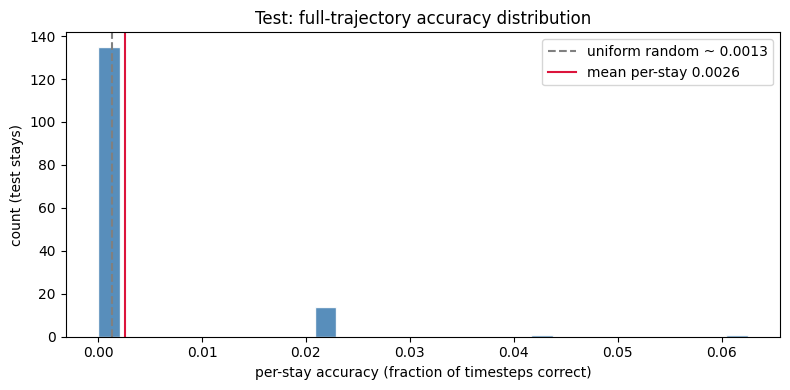

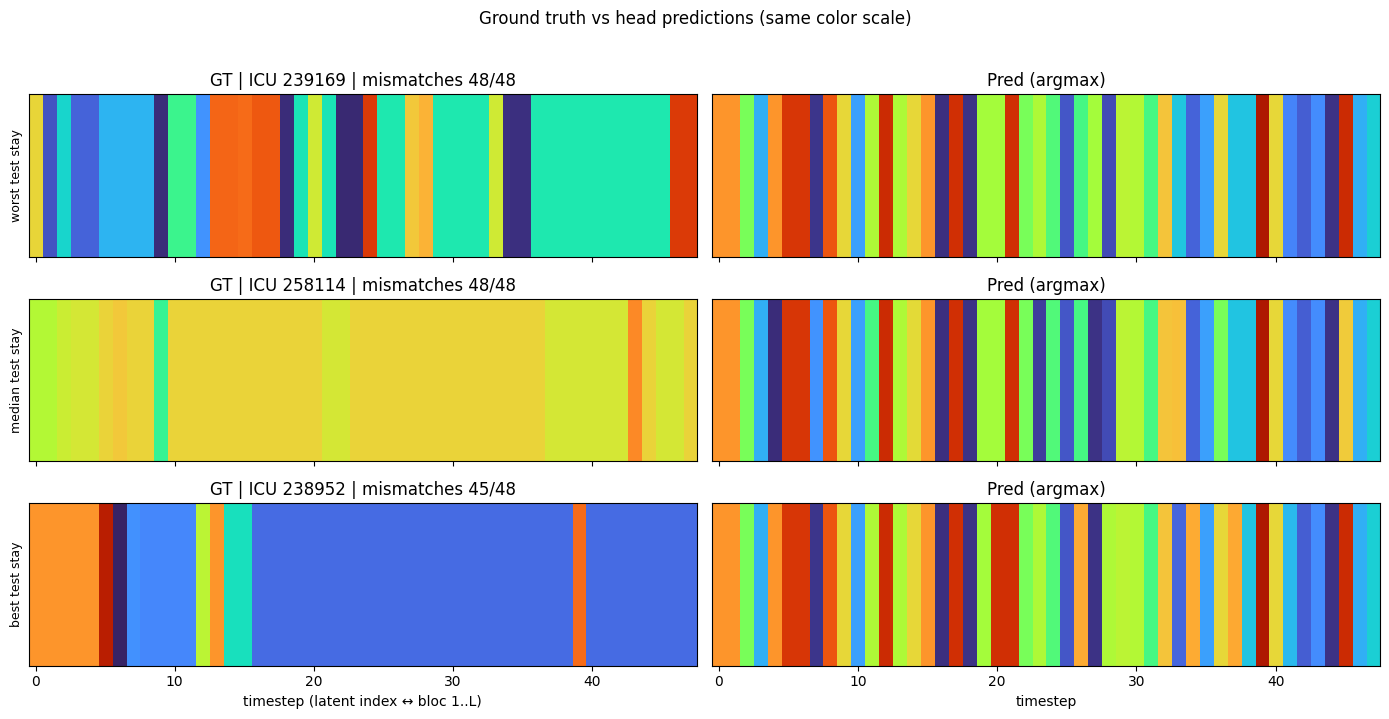

Appended trajectory_eval to /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/copers_to_states/models/coper_2node_drop0.5_s1_e3_per_step_state_head.pt


In [12]:
import matplotlib.pyplot as plt


@torch.no_grad()
def forward_predictions_per_stay(
    head: SharedPerStepStateHead,
    H: torch.Tensor,
    Y: torch.Tensor,
    batch_size: int = 256,
) -> tuple[torch.Tensor, np.ndarray]:
    """Return pred (N, L) int64 on CPU and per_stay_acc (N,) float — fraction of steps correct per stay."""
    head.eval()
    pred_chunks: list[torch.Tensor] = []
    frac_chunks: list[np.ndarray] = []
    n = int(H.shape[0])
    for i in range(0, n, batch_size):
        hb = H[i : i + batch_size].to(DEVICE)
        yb = Y[i : i + batch_size]
        logits = head(hb)
        pred_b = logits.argmax(dim=-1).cpu()
        pred_chunks.append(pred_b)
        frac_chunks.append((pred_b == yb).float().mean(dim=1).numpy())
    pred = torch.cat(pred_chunks, dim=0)
    per_stay = np.concatenate(frac_chunks, axis=0)
    return pred, per_stay


def trajectory_split_summary(split: str) -> dict:
    H, Y = packs[split]["H"], packs[split]["Y"]
    _, acc_i = forward_predictions_per_stay(head, H, Y)
    return {
        "split": split,
        "n_stays": int(len(acc_i)),
        "mean_per_stay_acc": float(acc_i.mean()),
        "median_per_stay_acc": float(np.median(acc_i)),
        "std_per_stay_acc": float(acc_i.std()),
        "pct_stays_ge_2x_uniform": float((acc_i >= 2.0 * uniform_acc).mean()),
    }


traj_rows = [trajectory_split_summary(sp) for sp in ("train", "val", "test")]
traj_summary_df = pd.DataFrame(traj_rows)
display(traj_summary_df)

H_te, Y_te = packs["test"]["H"], packs["test"]["Y"]
icu_te = packs["test"]["icustay_id"]
pred_te, acc_te = forward_predictions_per_stay(head, H_te, Y_te)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(acc_te, bins=30, color="steelblue", edgecolor="white", alpha=0.9)
ax.axvline(uniform_acc, color="gray", linestyle="--", label=f"uniform random ~ {uniform_acc:.4f}")
ax.axvline(float(acc_te.mean()), color="crimson", linestyle="-", label=f"mean per-stay {acc_te.mean():.4f}")
ax.set_xlabel("per-stay accuracy (fraction of timesteps correct)")
ax.set_ylabel("count (test stays)")
ax.set_title("Test: full-trajectory accuracy distribution")
ax.legend()
plt.tight_layout()
plt.show()

order = np.argsort(acc_te)
idx_worst, idx_med, idx_best = int(order[0]), int(order[len(order) // 2]), int(order[-1])
vmax = max(N_STATES - 1, 1)

fig, axes = plt.subplots(3, 2, figsize=(14, 7), sharex=True)
for row, (idx, label) in enumerate(
    ((idx_worst, "worst test stay"), (idx_med, "median test stay"), (idx_best, "best test stay"))
):
    gt = Y_te[idx].numpy()
    pr = pred_te[idx].numpy()
    mism = int((gt != pr).sum())
    axes[row, 0].imshow(gt.reshape(1, -1), aspect="auto", cmap="turbo", vmin=0, vmax=vmax, interpolation="nearest")
    axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(label, rotation=90, size=9)
    axes[row, 0].set_title(f"GT | ICU {int(icu_te[idx])} | mismatches {mism}/{L}")
    axes[row, 1].imshow(pr.reshape(1, -1), aspect="auto", cmap="turbo", vmin=0, vmax=vmax, interpolation="nearest")
    axes[row, 1].set_yticks([])
    axes[row, 1].set_title("Pred (argmax)")
axes[-1, 0].set_xlabel("timestep (latent index ↔ bloc 1..L)")
axes[-1, 1].set_xlabel("timestep")
plt.suptitle("Ground truth vs head predictions (same color scale)", y=1.02)
plt.tight_layout()
plt.show()

_ckpt = torch.load(out_path, map_location="cpu")
_ckpt["trajectory_eval"] = {
    "per_stay_summary": traj_rows,
    "test_example_icu": {
        "worst": int(icu_te[idx_worst]),
        "median": int(icu_te[idx_med]),
        "best": int(icu_te[idx_best]),
    },
    "test_example_acc": {
        "worst": float(acc_te[idx_worst]),
        "median": float(acc_te[idx_med]),
        "best": float(acc_te[idx_best]),
    },
}
torch.save(_ckpt, out_path)
print("Appended trajectory_eval to", out_path)